**A Structured Output Agent in LangChain (or other LLM frameworks) refers to an agent that produces responses in a specific structured
format, such as JSON, dictionaries, or other structured data types. These agents are particularly useful when you want to ensure that
your responses conform to a defined schema, making it easier to parse, validate, and utilize in downstream applications.**

#### Why Use a Structured Output Agent?

- Controlled Responses: Ensures that the outputs follow a specific format, reducing ambiguity.
- Data Validation: Useful when you want the model output to fit predefined structures, like for APIs or database entries.
- Automation: Makes integration with systems like dashboards, ETL pipelines, or business workflows easier.

In [2]:
from langchain_community.tools import TavilySearchResults
from langchain.tools import tool

In [3]:
from pydantic import BaseModel, Field

In [4]:
from langgraph.graph import MessagesState, StateGraph, END
from langgraph.prebuilt import ToolNode
from langchain_core.messages import HumanMessage

In [5]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="moonshotai/kimi-k2-instruct-0905")

In [14]:
llm.invoke("Who are You?").content

"I'm Kimi, your intelligent companion and a good friend. I can assist you with a wide range of things such as answering questions, helping with language translation, and more. Let me know how I can assist you!"

In [6]:
tavily_tool=TavilySearchResults(max_results=2)

C:\Users\USER\AppData\Local\Temp\ipykernel_3704\2795802001.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_tool=TavilySearchResults(max_results=2)


In [7]:
@tool
def get_city_details(prompt):
    "If city details are needed, use this tool to get them"
    response=tavily_tool.invoke(prompt)
    return response

In [8]:
tools=[get_city_details]

In [9]:
# binding the tools to the model, this will allow the model to call the tools when needed
model_with_tools=llm.bind_tools(tools)

In [10]:
model_with_tools

RunnableBinding(bound=ChatGroq(profile={'max_input_tokens': 262144, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000019554EB6270>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000019554EB6F90>, model_name='moonshotai/kimi-k2-instruct-0905', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'get_city_details', 'description': 'If city details are needed, use this tool to get them', 'parameters': {'properties': {'prompt': {}}, 'required': ['prompt'], 'type': 'object'}}}]}, config={}, config_factories=[])

The `BaseModel` class is a core component of Pydantic, which is used extensively in Python applications for data validation, type checking, and parsing. It's particularly useful when working with APIs, web frameworks like FastAPI, and other scenarios where you need to enforce data structure and ensure data integrity.

Here's an overview of the `BaseModel` class, along with some examples to demonstrate how you can use it effectively:

### Explanation:

- **Class Definition:**
  - `CityDetails` inherits from `BaseModel`, making it a data validation model.

- **Fields with Type Annotations:**
  - `state_name`: A string representing the state name of a city.
  - `state_capital`: A string representing the capital of that state.
  - `country_name`: A string representing the country name where the city is located.
  - `country_capital`: A string representing the capital of that country.

### Field Descriptions:

- Each field uses `Field()` to provide a description that helps clarify what information each attribute represents.

### Purpose:

- The model validates and structures data related to cities.
- Useful for ensuring that any data related to cities has the correct structure before processing.
- Helpful in APIs (like FastAPI) to generate self-documenting endpoints.

In [17]:
class CityDetails(BaseModel):
    """Respond to the user with this"""
    state_name: str= Field(description="State name of the city")
    state_capital: str= Field(description="State capital of the city")
    country_name :str= Field(description="Country name of the city")
    country_capital :str= Field(description="Country capital of the city")

In [19]:
# Inherit 'messages' key from MessagesState, which is a list of chat messages
class AgentState(MessagesState):
    # Final structure of the response we want to get from the agent
    final_response: CityDetails

In [20]:
model_with_structured_output=llm.with_structured_output(CityDetails)

In [21]:
def call_model(state: AgentState):
    print(f'this is 01 input from call model {state}')
    response=model_with_tools.invoke(state['messages'])
    print(f'this is 02 response from call model {response}')
    # we return a list, because this will get added to the existing list
    return {'messages':[response]}

In [22]:
def should_continue(state: AgentState):
    messages=state['messages']
    last_message=messages[-1]
    
    # If there is no function call , then responding to the user
    if not last_message.tool_calls:
        return 'respond'
    else:
        return "continue"
    
    

In [23]:
def respond(state: AgentState):
    print(f'this is 03 input from respond {state}')
    response=model_with_structured_output.invoke([HumanMessage(content=state['messages'][-1].content)])
    # returing the final answer
    print(f'this is 04 response from respond {response}')
    return {'final_response':response}

In [ ]:
# Define a new graph
workflow=StateGraph(AgentState) 

# define the two node we will cycle between
workflow.add_node('llm',call_model)
workflow.add_node('tools',ToolNode(tools))
workflow.add_node('respond',respond)


In [27]:
# Set the entry point as 'agent'
# this means that this nodes is the first one called
workflow.set_entry_point('llm')

In [28]:
# Now add a conditional edge
workflow.add_conditional_edges(
    'llm',
    
    should_continue,
    {
        'continue':'tools',
        'respond':'respond'
    }
)

In [29]:
workflow.add_edge('tools','llm')
workflow.add_edge('respond',END)
graph=workflow.compile()

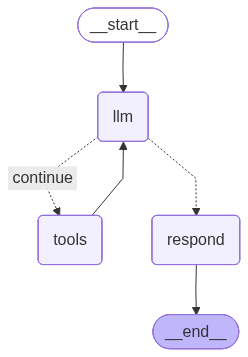

In [30]:
graph

In [32]:
answer=graph.invoke(
    input={'messages':[('human', "Tell me about the city details for gwalior")]}
)

this is 01 input from call model {'messages': [HumanMessage(content='Tell me about the city details for gwalior', additional_kwargs={}, response_metadata={}, id='1f3bb3a0-0f79-40f6-a616-7a9900d19452')]}
this is 02 response from call model content='' additional_kwargs={'tool_calls': [{'id': 'functions.get_city_details:0', 'function': {'arguments': '{"prompt":"gwalior"}', 'name': 'get_city_details'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 101, 'total_tokens': 121, 'completion_time': 0.074603921, 'completion_tokens_details': None, 'prompt_time': 0.262688737, 'prompt_tokens_details': None, 'queue_time': 1.57709042, 'total_time': 0.337292658}, 'model_name': 'moonshotai/kimi-k2-instruct-0905', 'system_fingerprint': 'fp_05df423bab', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019d1bf4-221c-7901-98b5-47d788985be7-0' tool_calls=[{'name': 'get_city_details', 'args':

In [33]:
answer

{'messages': [HumanMessage(content='Tell me about the city details for gwalior', additional_kwargs={}, response_metadata={}, id='1f3bb3a0-0f79-40f6-a616-7a9900d19452'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'functions.get_city_details:0', 'function': {'arguments': '{"prompt":"gwalior"}', 'name': 'get_city_details'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 101, 'total_tokens': 121, 'completion_time': 0.074603921, 'completion_tokens_details': None, 'prompt_time': 0.262688737, 'prompt_tokens_details': None, 'queue_time': 1.57709042, 'total_time': 0.337292658}, 'model_name': 'moonshotai/kimi-k2-instruct-0905', 'system_fingerprint': 'fp_05df423bab', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d1bf4-221c-7901-98b5-47d788985be7-0', tool_calls=[{'name': 'get_city_details', 'args': {'prompt': 'gwalior'}, 'id': 'functions.get_city_deta